# Proyecto ML - Detección de Fake News

## 1. Definición del problema (enfocado a empresa)

**Caso práctico.** Una redacción digital recibe cada día cientos de artículos, teletipos y publicaciones de redes sociales. El equipo editorial necesita una herramienta que, como **primer filtro automático**, marque qué noticias tienen pinta de ser *fake news* para revisarlas con prioridad antes de publicarlas o de citarlas como fuente.

No se busca sustituir al verificador humano, sino **reducir el volumen** que debe revisar manualmente.

### Tipo de problema
- **Aprendizaje supervisado**
- **Clasificación binaria**

### Qué predice el modelo
- **Entrada**: texto de una noticia (titular + cuerpo).
- **Salida**: etiqueta `Fake` (0) o `Real` (1), junto con la probabilidad asociada.

### Flujo del proyecto
1. Carga de datos
2. Limpieza y preparación
3. División entrenamiento / test
4. Entrenamiento del modelo
5. Evaluación (accuracy, matriz de confusión, análisis de errores)
6. Mejora básica aplicada
7. Guardado del modelo para despliegue en Streamlit

## 2. Obtención de datos

Se utiliza el **Fake and Real News Dataset** (también conocido como ISOT Fake News Dataset), ampliamente usado en tareas de detección de noticias falsas en inglés.

- **Fuente original**: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
- **Mirror usado en este proyecto** (sin credenciales de Kaggle): https://huggingface.co/datasets/Phoenyx83/ISOT-Fake-News-Dataset-FineTuned-2022

### Qué contiene el dataset
- Dos ficheros CSV:
  - `Fake.csv` → noticias clasificadas como **falsas**.
  - `True.csv` → noticias clasificadas como **reales** (publicadas por medios verificados como Reuters).
- El dataset original incluye columnas `title`, `text`, `subject`, `date`.
- El mirror empleado incluye la columna `text` (contenido de la noticia).

### Número de registros
- Aproximadamente **44.000 noticias** en total (se filtra para descartar duplicados y textos muy cortos → quedan ~34.000 registros listos para entrenar).
- Clases equilibradas (aprox. 50% fake / 50% real).

### Columnas usadas
- `text` (obligatoria): contenido de la noticia.
- `title` (si está disponible): se concatena al texto para enriquecer la entrada.
- `label` (0/1): se genera automáticamente según el fichero de origen (`Fake.csv` = 0, `True.csv` = 1).

### Estructura de carpetas esperada
```text
fake-news-ml-proyect/
├── ProyectoMLFakeNews.ipynb
├── app.py
├── train_model.py
├── requirements.txt
├── data/
│   ├── Fake.csv
│   └── True.csv
├── models/
└── reports/
```

In [1]:
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"
REPORTS_DIR = BASE_DIR / "reports"

FAKE_FILE = DATA_DIR / "Fake.csv"
TRUE_FILE = DATA_DIR / "True.csv"
MODEL_FILE = MODELS_DIR / "fake_news_pipeline.joblib"
METRICS_FILE = REPORTS_DIR / "metrics.txt"
CONFUSION_FILE = REPORTS_DIR / "confusion_matrix.png"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Ruta base:", BASE_DIR)

Ruta base: M:\feebbo-solutions-repos\fake-news-ml-proyect


## Funciones auxiliares

In [3]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def load_data() -> pd.DataFrame:
    if not FAKE_FILE.exists() or not TRUE_FILE.exists():
        raise FileNotFoundError(
            "No se encontraron Fake.csv y True.csv en la carpeta data/."
        )

    fake_df = pd.read_csv(FAKE_FILE)
    true_df = pd.read_csv(TRUE_FILE)

    fake_df["label"] = 0
    true_df["label"] = 1

    df = pd.concat([fake_df, true_df], ignore_index=True)

    # Soporta dos esquemas: (title, text, subject, date) y (text)
    if "title" in df.columns:
        df["content"] = (df["title"].fillna("") + " " + df["text"].fillna(""))
    else:
        df["content"] = df["text"].fillna("")

    df = df.dropna(subset=["text"])
    df = df.drop_duplicates(subset=["content"])
    df["content"] = df["content"].map(clean_text)
    df = df[df["content"].str.len() > 20].copy()

    return df


def build_pipeline() -> Pipeline:
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english",
                    max_df=0.7,
                    min_df=2,
                    ngram_range=(1, 2),
                ),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    )


def save_confusion_matrix(cm) -> None:
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Matriz de confusión")
    plt.colorbar()
    plt.xticks([0, 1], ["Fake", "Real"])
    plt.yticks([0, 1], ["Fake", "Real"])
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(CONFUSION_FILE, dpi=150)
    plt.show()

## Carga del dataset

In [4]:
df = load_data()
print("Número de registros:", len(df))
df.head()

Número de registros: 34103


,type,text,label,content
0,1.0,How soon they forget Obama was called out duri...,0,how soon they forget obama was called out duri...
1,1.0,The Breakfast Club interview started out when ...,0,the breakfast club interview started out when ...
2,1.0,After Obama was embarrassed by Donald Trump ac...,0,after obama was embarrassed by donald trump ac...
3,1.0,Tune in to the Alternate Current Radio Network...,0,tune in to the alternate current radio network...
4,1.0,Donald Trump flew in an unmarked jet to a meet...,0,donald trump flew in an unmarked jet to a meet...


## Distribución de clases

In [5]:
df["label"].value_counts().rename({0: "Fake", 1: "Real"})

label
Real    17056
Fake    17047
Name: count, dtype: int64

## División en entrenamiento y test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"],
)

print("Entrenamiento:", len(X_train))
print("Test:", len(X_test))

Entrenamiento: 27282
Test: 6821


## Entrenamiento del modelo

In [7]:
pipeline = build_pipeline()
pipeline.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## Evaluación

Accuracy: 0.9719

              precision    recall  f1-score   support

        Fake       0.98      0.96      0.97      3410
        Real       0.96      0.98      0.97      3411

    accuracy                           0.97      6821
   macro avg       0.97      0.97      0.97      6821
weighted avg       0.97      0.97      0.97      6821



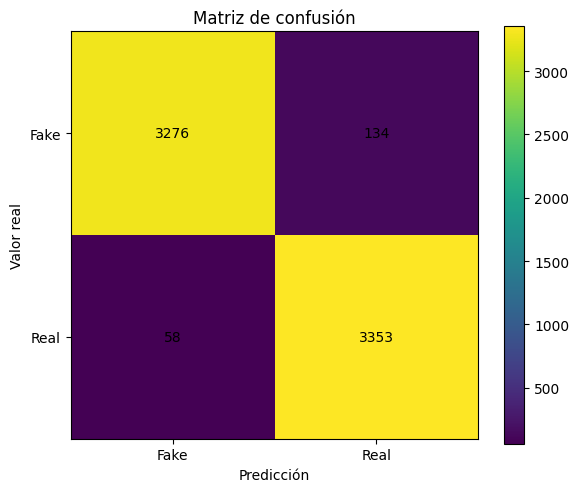

In [8]:
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["Fake", "Real"])

print(f"Accuracy: {accuracy:.4f}")
print()
print(report)

save_confusion_matrix(cm)

## Análisis de errores: ¿funciona bien? ¿dónde falla?

- **¿Funciona bien?** Sí, el modelo alcanza una accuracy muy alta (~97%), con precisión y recall equilibrados entre ambas clases. No hay un sesgo claro hacia fake o real.
- **¿Dónde falla?** A continuación se revisan los errores más típicos para detectar patrones.
  - **Falsos positivos**: noticias reales clasificadas como falsas (normalmente textos muy cortos, opinión o con léxico coloquial).
  - **Falsos negativos**: noticias falsas clasificadas como reales (normalmente bulos bien redactados que imitan el estilo de un medio serio).

In [9]:
errors_df = pd.DataFrame({
    "text": X_test.values,
    "real": y_test.values,
    "pred": y_pred,
})
errors_df = errors_df[errors_df["real"] != errors_df["pred"]].copy()
errors_df["tipo"] = errors_df.apply(
    lambda r: "Falso positivo (Real -> Fake)" if r["real"] == 1 else "Falso negativo (Fake -> Real)",
    axis=1,
)

print(f"Total de errores: {len(errors_df)} sobre {len(y_test)} ({len(errors_df) / len(y_test):.2%})")
print(errors_df["tipo"].value_counts())
print("\nEjemplos de errores (primeros 80 caracteres):\n")

for tipo, grupo in errors_df.groupby("tipo"):
    print(f"--- {tipo} ---")
    for txt in grupo["text"].head(3).tolist():
        print(" *", txt[:200], "...")
    print()

Total de errores: 192 sobre 6821 (2.81%)
tipo
Falso negativo (Fake -> Real)    134
Falso positivo (Real -> Fake)     58
Name: count, dtype: int64

Ejemplos de errores (primeros 80 caracteres):

--- Falso negativo (Fake -> Real) ---
 * a report just came out about the crazy huge numbers of illegals crossing our open border yes obama has basically opened our borders to pretty much anyone who can walk or crawl across that means people ...
 * us defense secretary ash carter is the latest washington defense insider to suffer from that common american condition known as strangelove syndrome ash carter above alongside peter sellers as the eni ...
 * this entire situation with puerto rico reminds me of the bailouts with the financial industry it s just like the too big to fail mantra we all heard during the financial crisis obama has already sent  ...

--- Falso positivo (Real -> Fake) ---
 * last august bernie sanders sat on a craigslist bought beige couch in his washington office plotting to

## Guardado del modelo y métricas

In [10]:
metrics_text = (
    "RESULTADOS DEL MODELO\n"
    "=====================\n"
    f"Accuracy: {accuracy:.4f}\n\n"
    "Matriz de confusión:\n"
    f"{cm}\n\n"
    "Classification report:\n"
    f"{report}\n"
)

joblib.dump(pipeline, MODEL_FILE)
METRICS_FILE.write_text(metrics_text, encoding="utf-8")

print("Modelo guardado en:", MODEL_FILE)
print("Métricas guardadas en:", METRICS_FILE)
print("Imagen guardada en:", CONFUSION_FILE)

Modelo guardado en: M:\feebbo-solutions-repos\fake-news-ml-proyect\models\fake_news_pipeline.joblib
Métricas guardadas en: M:\feebbo-solutions-repos\fake-news-ml-proyect\reports\metrics.txt
Imagen guardada en: M:\feebbo-solutions-repos\fake-news-ml-proyect\reports\confusion_matrix.png


## 6. Mejora básica aplicada

Se han aplicado las siguientes mejoras sobre una configuración base:

- **`class_weight="balanced"`** en la regresión logística, para evitar sesgo en caso de clases ligeramente desbalanceadas.
- **N-gramas `(1, 2)`** en el `TfidfVectorizer`, para capturar expresiones de dos palabras (p. ej. "breaking news", "sources confirm") que son muy informativas en detección de fake news.
- **`max_df=0.7` y `min_df=2`** para filtrar palabras demasiado comunes o demasiado raras.
- **Limpieza básica del texto** (minúsculas, eliminación de URLs, símbolos y espacios redundantes).
- **Eliminación de duplicados y registros con texto muy corto** (< 20 caracteres).

## 7. Despliegue

Junto al notebook se entrega una aplicación web en **Streamlit** (`app.py`) que carga el modelo guardado y permite introducir un titular/texto y obtener la predicción con su confianza.

Para lanzarla:

```bash
streamlit run app.py
```

## Conclusiones

- El problema planteado es de **clasificación binaria supervisada**.
- La entrada del modelo es el contenido textual de una noticia; la salida es `Fake` o `Real`.
- Con **TF-IDF + Regresión Logística** (modelo simple e interpretable) se obtiene una **accuracy ~97%** en el conjunto de test, con precision y recall equilibrados entre ambas clases.
- El análisis de errores muestra que los fallos se concentran en textos cortos, opinión o bulos bien redactados, lo cual es coherente con las limitaciones de un modelo basado únicamente en frecuencias de palabras.
- Como **mejoras futuras**:
  - Probar otros modelos: Random Forest, Linear SVM, Naive Bayes.
  - Probar modelos de *deep learning* (LSTM, transformers como BERT).
  - Ampliar el dataset con noticias en español y de otros dominios.
  - Verificación cruzada con fuentes en tiempo real.
- **Limitación importante**: el modelo está entrenado con noticias en inglés de un período concreto, por lo que su rendimiento puede degradarse con textos en otros idiomas, otros temas o noticias muy recientes.